In [1]:
import time
import os
import sys
import copy
import numpy as np
import torch
import torch.optim as optim
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torchsummary import summary
from google.colab import drive

# **DATA LOADING**

In [2]:
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/')
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/DATA/GALAH/'

Mounted at /content/drive


# **DEVICE SETTING**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **HELPER FUNCTIONS**

In [4]:
def normalize(labels, p):

    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):

    return labels * (ranges[1] - ranges[0]) + ranges[0]

def denormalize_std(uncertainty, ranges):

    return uncertainty * (ranges[1] - ranges[0])


def get_normalized_data(data_path, return_SNR=False):

    # Load the spectra data
    spectra = np.load(f"{data_path}/spectra.npy")
    spectra_length = spectra.shape[1]

    # Load the labels data
    # labels: mass, age, l_bol, dist, t_eff, log_g, fe_h
    labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h"]
    labels = np.load(f"{data_path}/labels.npy")
    SNR = labels[:, -1]
    labels = labels[:, :-1]

    # We only use the labels: t_eff, log_g, fe_h
    labelNames = labelNames[-3:]
    labels = labels[:, -3:]
    n_labels = labels.shape[1]

    labels, ranges = normalize(labels, 0.05)

    # Normalize spectra
    spectra = np.log(np.maximum(spectra, 0.2))

    if return_SNR:
        return spectra, labels, spectra_length, n_labels, labelNames, ranges, SNR
    return spectra, labels, spectra_length, n_labels, labelNames, ranges

# **CNN MODEL**

In [5]:
class TinyCNN(nn.Module):
	def __init__(self, nLabels):
		super(TinyCNN, self).__init__()

		self.model = nn.Sequential(
			nn.Conv1d(1, 10, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(10, 20, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(20),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(20, 40, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(40),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(40, 10, kernel_size=1),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(2),

			nn.Conv1d(10, 12, kernel_size=3),
			nn.ReLU(),
			nn.BatchNorm1d(12),
			nn.Dropout(0.2),

			nn.Conv1d(12, 10, kernel_size=1),
			nn.Dropout(0.2),

			nn.Linear(300, 32), # batch, filters, * -> batch, filters, 32
			nn.ReLU(),
			nn.Flatten(),
			nn.Linear(10*32, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, nLabels * 2)

		)

	def forward(self, x):
		# x = torch.unsqueeze(x,1)
		x = self.model(x)
		return x


# **TRAIN MODEL FUNCTION**

In [6]:
def train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):


    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()  # Start the timer for this epoch

        # Training phase
        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)  # Add channel dimension for CNNs
            predictions = model(batch_spectra)
            optimizer.zero_grad()

            # Correctly pass predictions, true labels, and the number of labels to the loss function
            loss=loss_function(predictions, batch_labels, batch_labels.shape[1])

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Print progress every 10th step, updating the same line
            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")  # Move to the next line after the epoch

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)

                predictions = model(batch_spectra)
                # Correctly pass predictions, true labels, and the number of labels to the loss function
                val_loss=loss_function(predictions, batch_labels, batch_labels.shape[1])

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Print epoch summary
        epoch_time = time.time() - start_time  # Calculate epoch time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if(epoch%plot_interval==0):
            if(plot_fn is not None):

                assert(plot_kwargs is not None)

                assert("test_loader" in plot_kwargs.keys())
                assert("ranges" in plot_kwargs.keys())
                assert("plot_folder" in plot_kwargs.keys())

                plot_fn(model,
                        plot_kwargs["test_loader"],
                        loss_function,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)

    return train_losses, val_losses, best_model

# **EVALUATE MODEL FUNCTION**

In [7]:
def evaluate_model(model, test_loader, loss_function, device):

    print("Evaluating model on the test dataset...")
    model.eval()
    total_test_loss = 0.0
    all_predictions = []
    all_uncertainties = []
    all_true_labels = []

    first_batch_spectra=None
    first_batch_labels=None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device).unsqueeze(1), batch_labels.to(device)
            predictions = model(batch_spectra)

            #split the outputs
            n = batch_labels.shape[1]
            mean = predictions[:, :n]
            log_std = predictions[:, n:]
            std = torch.exp(log_std)

            # Apply loss function
            test_loss = loss_function(predictions, batch_labels, n)

            total_test_loss += test_loss.item()
            all_predictions.append(mean.cpu())
            all_uncertainties.append(std.cpu())
            all_true_labels.append(batch_labels.cpu())

            if(batch_index==0):
                first_batch_spectra=batch_spectra
                first_batch_labels=batch_labels

    avg_test_loss = total_test_loss / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_uncertainties).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels

# **APPLYING MODEL TO DATA**

In [12]:
# Hyperparameters
learning_rate = 1e-4
batch_size = 128
num_epochs = 100
patience = 30 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7 # Fraction of the data used for training
val_fraction = 0.15 # Fraction of the data used for validation

# Call the function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH, return_SNR=False)

# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model selection
model_choice = 'tiny_CNN'

if model_choice == 'tiny_CNN':
    model = TinyCNN(n_labels)
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Print the model summary before moving it to the device
summary(model, input_size=(1, spectra_length))


def nnl_loss(predictions, labels, n_labels):
  mean = predictions[:, :n_labels]
  log_std = predictions[:, n_labels:]
  std = torch.exp(log_std)
  return torch.mean(0.5 * ((labels - mean) / std )**2 + log_std)


# Call the function
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, nnl_loss, learning_rate, num_epochs, patience, device)

# Final evaluation on the test dataset
model.load_state_dict(best_model)  # Load the best model
# save the best model to the "models" directory
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(best_model, f'models/{model_choice}_best.pth')
model.to(device)

# Correctly capture the returned values
predictions_output, uncertainties_output, true_labels_output, _, _ = evaluate_model(model, test_loader, nnl_loss, device)

# Denormalize predictions, true labels and uncertanties
all_predictions = denormalize(predictions_output, ranges)
all_true_labels = denormalize(true_labels_output, ranges)
all_uncertainties_= denormalize_std(uncertainties_output, ranges)

Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 10, 16380]              60
              ReLU-2            [-1, 10, 16380]               0
       BatchNorm1d-3            [-1, 10, 16380]              20
           Dropout-4            [-1, 10, 16380]               0
         AvgPool1d-5             [-1, 10, 5460]               0
            Conv1d-6             [-1, 20, 5456]           1,020
              ReLU-7             [-1, 20, 5456]               0
       BatchNorm1d-8             [-1, 20, 5456]              40
           Dropout-9             [-1, 20, 5456]               0
        AvgPool1d-10             [-1, 20, 1818]               0
           Conv1d-11             [-1, 40, 1814]           4,040
             ReLU-12             [-1, 40, 1814]               0
      BatchNorm1d-13             [-1, 40, 1814]              80
          Dropout-14

# **LOSS PLOT**

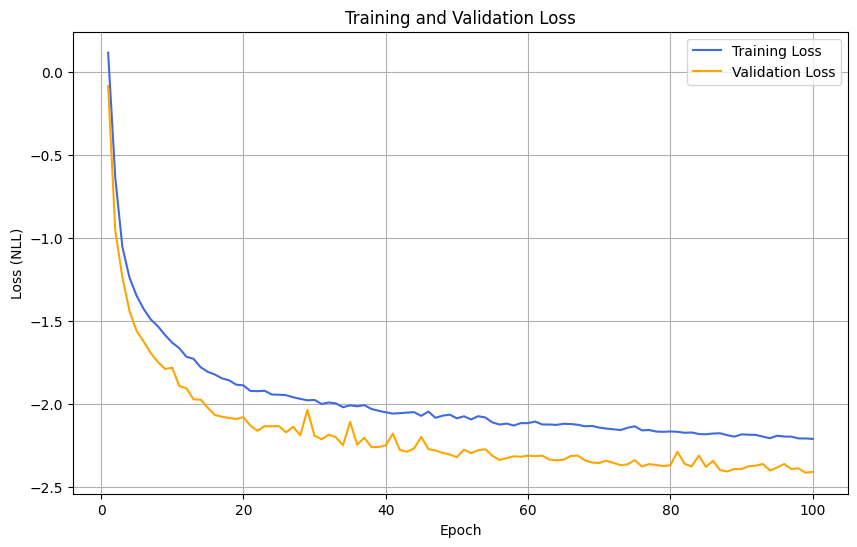

In [13]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color = 'royalblue')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color = 'orange')


plt.xlabel('Epoch')
plt.ylabel('Loss (NLL)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# **SCATTER PLOT**

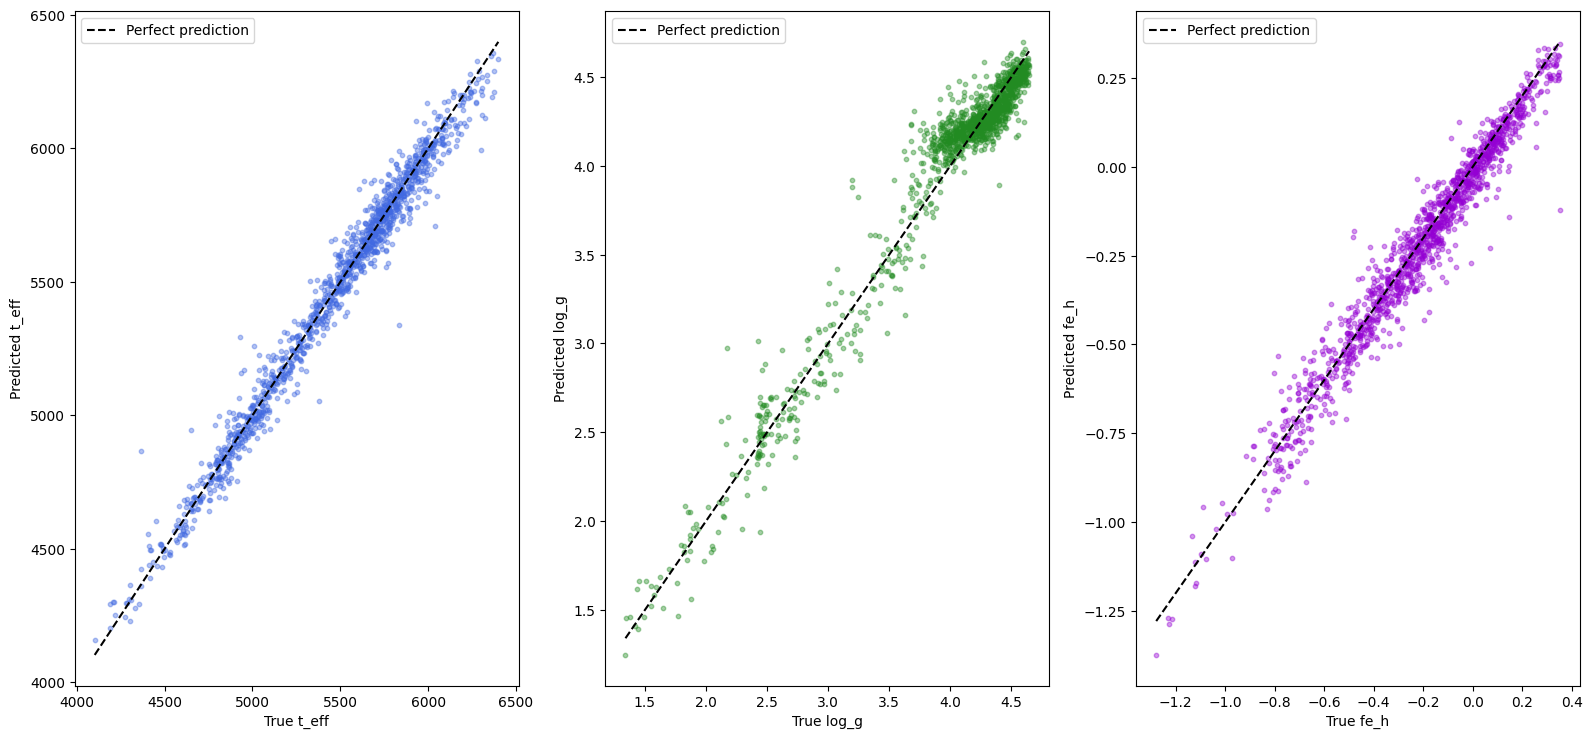

In [14]:
# Scatter plots for predictions
plt.figure(figsize=(16,7.5))
colors = ['royalblue', 'forestgreen', 'darkviolet']
for j, c in zip(range(n_labels), colors):
    plt.subplot(1,3,j+1)
    gt = all_true_labels
    plt.scatter(gt[:,j],y=all_predictions[:,j],s=10,alpha=0.4, color=c)
    plt.plot([gt[:,j].min().item(),gt[:,j].max().item()],[gt[:,j].min().item(),gt[:,j].max().item()],c="black",linestyle="dashed",label="Perfect prediction")
    plt.xlabel("True "+labelNames[j])
    plt.ylabel("Predicted "+labelNames[j])
    plt.legend()
plt.tight_layout()
plt.show()

# **PULL DISTRIBUTIONS**

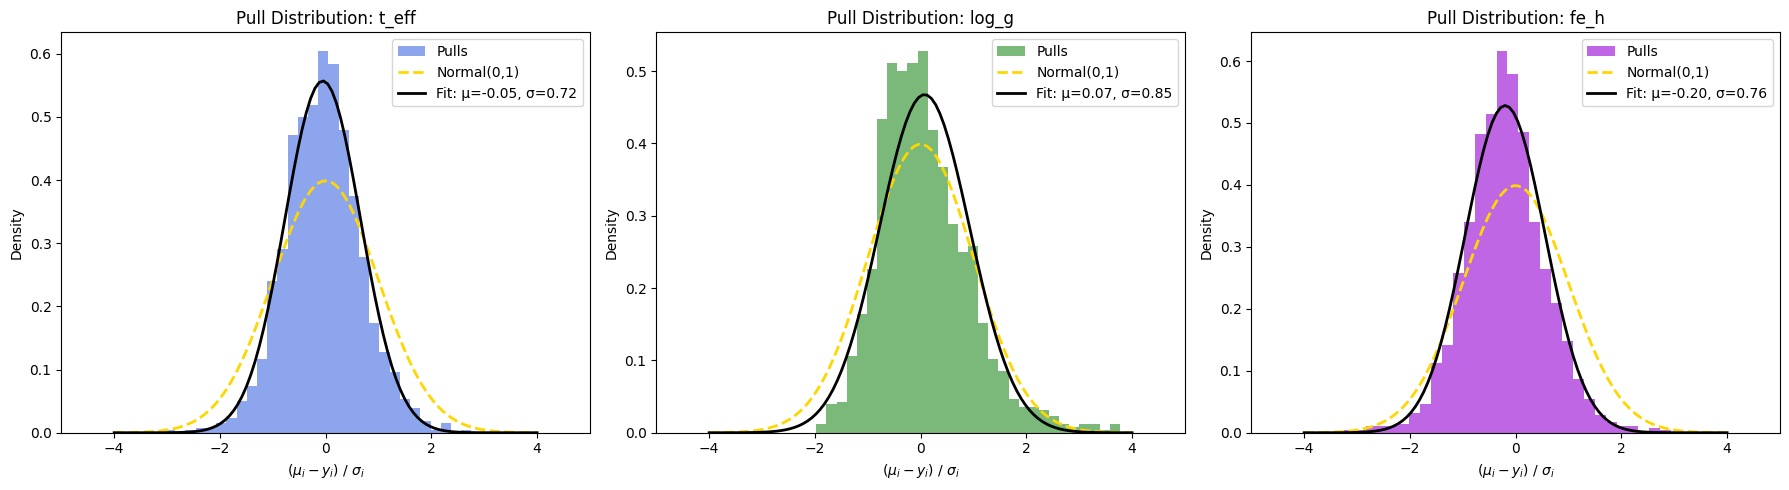

In [17]:
import scipy.stats as stats
pulls = (all_predictions - all_true_labels) / all_uncertainties_

plt.figure(figsize=(18, 5))

for i, c in zip(range(n_labels), colors):
    plt.subplot(1, 3, i + 1)

    # Plot histogram of pulls
    data = pulls[:, i]
    mu_pull, std_pull = np.mean(data), np.std(data)

    plt.hist(data, bins=30, density=True, alpha=0.6, color=c, label='Pulls')

    # Overplot the Standard Normal Distribution (Goal)
    x = np.linspace(-4, 4, 100)
    plt.plot(x, stats.norm.pdf(x, 0, 1), '--', lw=2, label='Normal(0,1)', color='gold')

    # Overplot the actual fit of the pulls
    plt.plot(x, stats.norm.pdf(x, mu_pull, std_pull), 'black', lw=2, label=f'Fit: μ={mu_pull:.2f}, σ={std_pull:.2f}')

    plt.title(f"Pull Distribution: {labelNames[i]}")
    plt.xlabel(r"($\mu_i - y_i$) / $\sigma_i$")
    plt.ylabel("Density")
    plt.xlim(-5, 5)
    plt.legend()

plt.tight_layout()
plt.show()